# DNN — Scikit-Learn Pipeline

## Model: Deep Neural Network (Multi-Layer Perceptron)
- **Dataset**: UCI HAR — 7,352 train / 2,947 test, 561 sensor features
- **Task**: Classify 6 human activities (3 dynamic, 3 static)
- **Framework showcase**: Activation function comparison (ReLU vs Tanh vs Logistic)

## Evaluation Strategy
- **Metrics**: Accuracy, Macro F1, per-class F1, confusion matrix
- **Training curves**: `loss_curve_` + `validation_scores_` (with early stopping)

## Pipeline
1. Load data + config
2. Simple baseline DNN
3. Training history visualization
4. Activation function comparison (showcase)
5. Architecture sweep
6. Best model — full evaluation
7. Performance benchmarks
8. Save results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

from sklearn.neural_network import MLPClassifier
from utils.data_loader import load_processed_data
from utils.visualization import (plot_confusion_matrix_multiclass,
                                  plot_per_class_f1, plot_training_history)
from utils.metrics import evaluate_classifier
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

import os
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "Scikit-Learn"
N_CLASSES = 6
ACTIVITY_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

# Step 1: Load preprocessed UCI HAR
X_train, X_test, y_train, y_test, meta = load_processed_data('dnn')

print("=" * 60)
print(f"[1/8] Data loaded — {FRAMEWORK} DNN")
print("=" * 60)
print(f"  Train: {X_train.shape} | Test: {X_test.shape}")
print(f"  Classes: {N_CLASSES} ({', '.join(ACTIVITY_NAMES)})")
print(f"  Label range: [{y_train.min()}, {y_train.max()}]")
print(f"  Dtype: {X_train.dtype}")

[1/8] Data loaded — Scikit-Learn DNN
  Train: (7352, 561) | Test: (2947, 561)
  Classes: 6 (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)
  Label range: [0, 5]
  Dtype: float32


In [ ]:
# Step 2: Simple baseline — single hidden layer, default settings

"""
MLPClassifier uses backprop with Adam optimizer by default
early_stopping=True holds out 10% of train for validation tracking
"""

print("=" * 60)
print("[2/8] SIMPLE BASELINE DNN")
print("=" * 60)

baseline = MLPClassifier(
    hidden_layer_sizes=(128,),  # single hidden layer, 128 neurons
    activation='relu',          # standard DNN activation
    solver='adam',              # adaptive learning rate optimizer
    max_iter=200,               # max epochs
    random_state=RANDOM_STATE,
    early_stopping=True,        # hold out 10% for validation
    validation_fraction=0.1,
    n_iter_no_change=15,        # patience before stopping
    verbose=False
)

with track_performance() as perf:
    baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
base_metrics = evaluate_classifier(y_test, y_pred_base)

print(f"\n  Architecture: 561 → 128 → 6")
print(f"  Epochs run: {baseline.n_iter_}")
print(f"  Final train loss: {baseline.loss_curve_[-1]:.4f}")
print(f"  Best val score: {max(baseline.validation_scores_):.4f}")
print(f"  Training time: {perf['time']:.2f}s")
print(f"\n  Test Results:")
print(f"    Accuracy: {base_metrics['accuracy']:.4f}")
print(f"    Macro F1: {base_metrics['macro_f1']:.4f}")

[2/8] SIMPLE BASELINE DNN

  Architecture: 561 → 128 → 6
  Epochs run: 30
  Final train loss: 0.0196
  Best val score: 0.9796
  Training time: 1.21s

  Test Results:
    Accuracy: 0.9440
    Macro F1: 0.9442


[3/8] TRAINING HISTORY


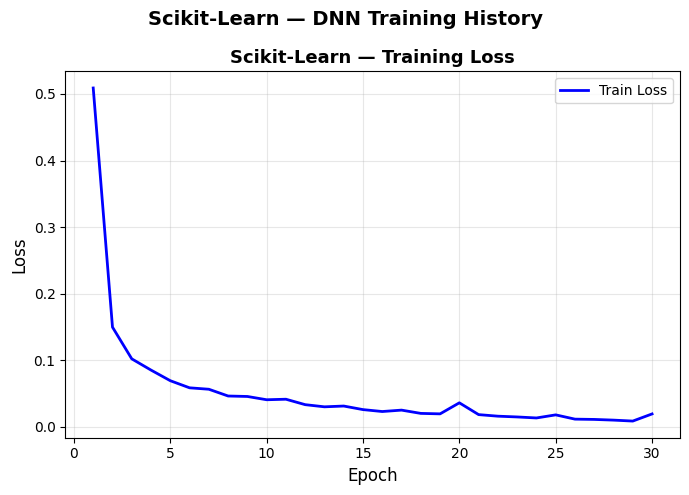

  Epochs: 30
  Loss: 0.5090 → 0.0196
  Val acc: 0.9280 → 0.9796


In [3]:
# Step 3: Visualize training curves from baseline

"""
MLPClassifier exposes loss_curve_ (train loss per epoch)
and validation_scores_ (accuracy on held-out 10%) when early_stopping=True
"""

print("=" * 60)
print("[3/8] TRAINING HISTORY")
print("=" * 60)

history = {
    'train_loss': baseline.loss_curve_,
    'val_acc': baseline.validation_scores_
}

plot_training_history(history, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_baseline.png')

print(f"  Epochs: {len(baseline.loss_curve_)}")
print(f"  Loss: {baseline.loss_curve_[0]:.4f} → {baseline.loss_curve_[-1]:.4f}")
print(f"  Val acc: {baseline.validation_scores_[0]:.4f} → {max(baseline.validation_scores_):.4f}")